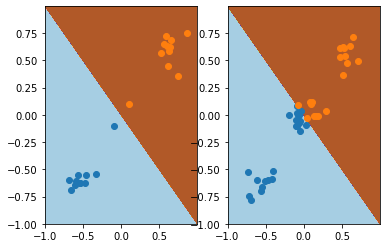

In [43]:
%matplotlib inline
import sys
sys.path.append('../functions')
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import sim_func 
import matplotlib.pyplot as plt
N = 100
error_sd = 1
level = 0
rng = np.random.default_rng(None)
beta = np.array([0,1,1])
# A grid for the true mean
x1grid = np.arange(-1, 1, 0.005)
x2grid = np.arange(-1, 1, 0.005)
xx, yy = np.meshgrid(x1grid, x2grid)
# flatten each grid to a vector
r1, r2 = xx.flatten(), yy.flatten()
r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
# horizontal stack vectors to create x1,x2 input for the model
grid = np.hstack((r1,r2))
_, _, X_grid, mean_grid = sim_func.generate_linear_data(N = N, N_test = None, beta = beta, error_sd = error_sd, X_test = grid)
boundary = (mean_grid >= level).astype(int)
# reshape the predictions back into a grid
zz = boundary.reshape(xx.shape)
# plot the grid of x, y and z values as a surface
fig, axs = plt.subplots(1, 2)
axs[0].contourf(xx, yy, zz, cmap='Paired')
# Generate test datset
X_test = np.array([[0.1,0.1],[-0.1,-0.1]])
X_test = np.concatenate([X_test, rng.standard_normal(size = (10,2))*0.1 +0.6,rng.standard_normal(size = (10,2))*0.1 -0.6])
_, _, X_test, mean_test = sim_func.generate_linear_data(N = N, N_test = None, beta = beta, error_sd = error_sd, X_test = X_test)
# get row indexes for samples with this class
row_ix1 = np.where(mean_test < level)
row_ix2 = np.where(mean_test >= level)
# create scatter of these samples
axs[0].scatter(X_test[row_ix1, 0], X_test[row_ix1, 1], cmap='Paired')
axs[0].scatter(X_test[row_ix2, 0], X_test[row_ix2, 1], cmap='Paired')

# Second plot
axs[1].contourf(xx, yy, zz, cmap='Paired')
# Generate test datset
X_test = np.array([[0.1,0.1],[-0.1,-0.1]])
X_test = np.concatenate([X_test, rng.standard_normal(size = (10,2))*0.1,rng.standard_normal(size = (10,2))*0.1,
                        rng.standard_normal(size = (10,2))*0.1 +0.6,rng.standard_normal(size = (10,2))*0.1 -0.6])
_, _, X_test, mean_test = sim_func.generate_linear_data(N = N, N_test = None, beta = beta, error_sd = error_sd, X_test = X_test)
# get row indexes for samples with this class
row_ix1 = np.where(mean_test < level)
row_ix2 = np.where(mean_test >= level)
# create scatter of these samples
axs[1].scatter(X_test[row_ix1, 0], X_test[row_ix1, 1], cmap='Paired')
axs[1].scatter(X_test[row_ix2, 0], X_test[row_ix2, 1], cmap='Paired')
fig.savefig("showcase_fig/showcase1.png")

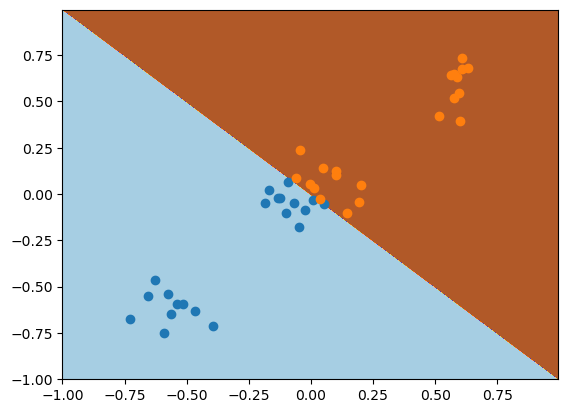

In [34]:
plt.contourf(xx, yy, zz, cmap='Paired')
# Generate test datset
X_test = np.array([[0.1,0.1],[-0.1,-0.1]])
X_test = np.concatenate([X_test, rng.standard_normal(size = (10,2))*0.1,rng.standard_normal(size = (10,2))*0.1,
                        rng.standard_normal(size = (10,2))*0.1 +0.6,rng.standard_normal(size = (10,2))*0.1 -0.6])
_, _, X_test, mean_test = sim_func.generate_linear_data(N = N, N_test = None, beta = beta, error_sd = error_sd, X_test = X_test)
# get row indexes for samples with this class
row_ix1 = np.where(mean_test < level)
row_ix2 = np.where(mean_test >= level)
# create scatter of these samples
plt.scatter(X_test[row_ix1, 0], X_test[row_ix1, 1], cmap='Paired')
plt.scatter(X_test[row_ix2, 0], X_test[row_ix2, 1], cmap='Paired')
plt.show()

In [ ]:
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import torch
import pandas as pd
import multiprocessing
import time
import sim_func 
N = 100
e = 0.001
error_sd = 1
level = 0.1
use_true_contour = False
rng = np.random.default_rng(None)
random_ind = False
if random_ind:
    p = 2
    N_test = 500
    beta = rng.standard_normal(size = p)
    X_test = rng.standard_normal(size = (N_test,p-1))
else:
    X_test = np.array([[0.9,0.11],[0.3,0.5],[0,2], [2, 0], [-2, 0.41],
                          [-1, 0.71],[0.5, 0.2],[3, 0.54],[-1, 0.21]])
    beta = np.array([0,1,1])
contain_v = []
y, X, X_test, mean_test_true = sim_func.generate_linear_data(N = N, N_test = N_test, beta = beta, error_sd = error_sd, X_test = X_test)
_, contain,index_set_len,contain_scb,contain_CS_scb,upper_bound,lower_bound,p0,p1,p2 = sim_func.linear_confidence_set_new2(y = y, X = X, X_test = X_test, mean_test_true = mean_test_true, level = level, e = None, n_boot = 1000, alpha = 0.05, use_true_contour = use_true_contour
                                                        )
contain_v.append(contain)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import make_moons, make_circles, make_classification
# from sklearn.neural_network import MLPClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
# from sklearn.gaussian_process import GaussianProcessClassifier
# from sklearn.gaussian_process.kernels import RBF
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# from sklearn.inspection import DecisionBoundaryDisplay

# names = [
#     "Nearest Neighbors",
#     "Linear SVM",
#     "RBF SVM",
#     "Gaussian Process",
#     "Decision Tree",
#     "Random Forest",
#     "Neural Net",
#     "AdaBoost",
#     "Naive Bayes",
#     "QDA",
# ]

# classifiers = [
#     KNeighborsClassifier(3),
#     SVC(kernel="linear", C=0.025),
#     SVC(gamma=2, C=1),
#     GaussianProcessClassifier(1.0 * RBF(1.0)),
#     DecisionTreeClassifier(max_depth=5),
#     RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
#     MLPClassifier(alpha=1, max_iter=1000),
#     AdaBoostClassifier(),
#     GaussianNB(),
#     QuadraticDiscriminantAnalysis(),
# ]

# X, y = make_classification(
#     n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
# )
# rng = np.random.RandomState(2)
# X += 2 * rng.uniform(size=X.shape)
# linearly_separable = (X, y)

# datasets = [
#     make_moons(noise=0.3, random_state=0),
#     make_circles(noise=0.2, factor=0.5, random_state=1),
#     linearly_separable,
# ]

# figure = plt.figure(figsize=(27, 9))
# i = 1
# # iterate over datasets
# for ds_cnt, ds in enumerate(datasets):
#     # preprocess dataset, split into training and test part
#     X, y = ds
#     X = StandardScaler().fit_transform(X)
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.4, random_state=42
#     )

#     x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
#     y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

#     # just plot the dataset first
#     cm = plt.cm.RdBu
#     cm_bright = ListedColormap(["#FF0000", "#0000FF"])
#     ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
#     if ds_cnt == 0:
#         ax.set_title("Input data")
#     # Plot the training points
#     ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
#     # Plot the testing points
#     ax.scatter(
#         X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
#     )
#     ax.set_xlim(x_min, x_max)
#     ax.set_ylim(y_min, y_max)
#     ax.set_xticks(())
#     ax.set_yticks(())
#     i += 1

#     # iterate over classifiers
#     for name, clf in zip(names, classifiers):
#         ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
#         clf.fit(X_train, y_train)
#         score = clf.score(X_test, y_test)
#         DecisionBoundaryDisplay.from_estimator(
#             clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
#         )

#         # Plot the training points
#         ax.scatter(
#             X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
#         )
#         # Plot the testing points
#         ax.scatter(
#             X_test[:, 0],
#             X_test[:, 1],
#             c=y_test,
#             cmap=cm_bright,
#             edgecolors="k",
#             alpha=0.6,
#         )

#         ax.set_xlim(x_min, x_max)
#         ax.set_ylim(y_min, y_max)
#         ax.set_xticks(())
#         ax.set_yticks(())
#         if ds_cnt == 0:
#             ax.set_title(name)
#         ax.text(
#             x_max - 0.3,
#             y_min + 0.3,
#             ("%.2f" % score).lstrip("0"),
#             size=15,
#             horizontalalignment="right",
#         )
#         i += 1

# plt.tight_layout()
# plt.show()